# Init

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
#%matplotlib inline
from datetime import datetime
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Set random seed for reproducibility
manualSeed = 999
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.use_deterministic_algorithms(False) # Needed for reproducible results, causes errors btw

Random Seed:  999


## Getting Dataset

In [2]:
!mkdir results models

mkdir: cannot create directory ‘results’: File exists
mkdir: cannot create directory ‘models’: File exists


In [3]:
#!mkdir drive/MyDrive/models
#!mkdir drive/MyDrive/results
!mkdir results/MRI/CGAN/ -p
!mkdir models/MRI/CGAN -p

In [4]:
# Upload your kaggle.json manually: from google.colab import files; files.upload()
!chmod 600 kaggle.json
!mkdir  -p /root/.kaggle
!cp kaggle.json /root/.kaggle/kaggle.json -r
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!mkdir -p data/celeba
!unzip -oq brain* -d Dataset/
!mv Dataset/Te* Dataset

mkdir: cannot create directory ‘/root’: Permission denied
cp: cannot stat '/root/.kaggle/kaggle.json': Permission denied
/usr/bin/bash: line 1: kaggle: command not found
unzip:  cannot find or open brain*, brain*.zip or brain*.ZIP.

No zipfiles found.
mv: cannot stat 'Dataset/Te*': No such file or directory


In [5]:
!ls Dataset/glioma | head

Te-gl_0010.jpg
Te-gl_0011.jpg
Te-gl_0012.jpg
Te-gl_0013.jpg
Te-gl_0014.jpg
Te-gl_0015.jpg
Te-gl_0016.jpg
Te-gl_0017.jpg
Te-gl_0018.jpg
Te-gl_0019.jpg
ls: write error: Broken pipe


# Data Loading

In [2]:
# Root directory for dataset
#dataroot = "data/Training"
dataroot = "Dataset"

# Number of workers for dataloader
workers = 2

# Batch size during training
batch_size = 256

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 64

# Number of channels in the training images. For color images this is 3
nc = 1

# Size of z latent vector (i.e. size of generator input)
nz = 100

# Size of feature maps in generator
ngf = 64

# Size of feature maps in discriminator
ndf = 64

# Number of training epochs
num_epochs = 25

# Learning rate for optimizers
lrG = 0.0002
lrD = 0.0002

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5
beta2 = 0.999

# Number of GPUs available. Use 0 for CPU mode.
ngpu = torch.cuda.is_available()

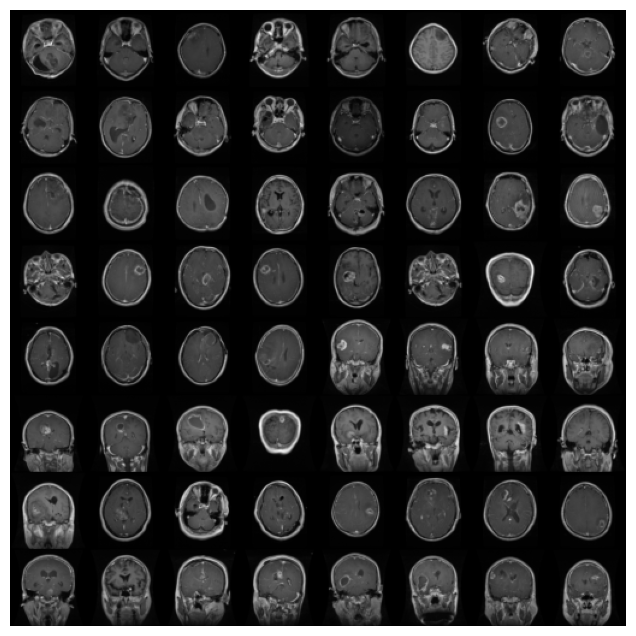

In [3]:
# We can use an image folder dataset the way we have it setup.
# Create the dataset
dataset = dset.ImageFolder(root=dataroot,
                           transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.Grayscale(num_output_channels=1),  # Convert to single-channel grayscale
                               transforms.ToTensor(),
                               transforms.RandomHorizontalFlip(p=0.5), # some kind of augmentation
                               #transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                               transforms.Normalize((0.5), (0.5)),
                           ]))
# Create the dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=False, num_workers=workers)

# Decide which device we want to run on
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

# Plot some training images
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
#plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=0, normalize=True).cpu(),(1,2,0)))
plt.show()

In [4]:
real_batch[0].shape

torch.Size([256, 1, 64, 64])

# Defining the model

In [5]:
import utils, torch, time, os, pickle
import numpy as np
import torch.nn as nn
import torch.optim as optim
import imageio
from PIL import Image

In [6]:
 from importlib import reload
 reload(utils)

<module 'utils' from '/home/sotch/code/MRI_GAN/utils.py'>

## The generator

In [ ]:
class generator(nn.Module):
    # Network Architecture is exactly same as in infoGAN (https://arxiv.org/abs/1606.03657)
    # Architecture : FC1024_BR-FC7x7x128_BR-(64)4dc2s_BR-(1)4dc2s_S
    def __init__(self, input_dim=100, output_dim=1, input_size=32, class_num=4 ):
        super(generator, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.input_size = input_size
        self.class_num = class_num
        self.class_embedding_dim = class_num*2


        self.label_embed = nn.Sequential(
            nn.Embedding(self.class_num, self.class_embedding_dim),
           # nn.Flatten(),
        )

        self.fc = nn.Sequential(
            nn.Linear(self.input_dim + self.class_embedding_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, 256 * (self.input_size // 8) * (self.input_size // 8)),
            nn.BatchNorm1d(256 * (self.input_size // 8) * (self.input_size // 8)),
            nn.ReLU(),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, self.output_dim, 4, 2, 1, bias=False),
            nn.Tanh(),
        )
        utils.initialize_weights(self)

    def forward(self, input, label):
        #label = self.label_embed(label.int())
        x = torch.cat([input, label], 1)
        x = self.fc(x)
        x = x.view(-1, 256, (self.input_size // 8), (self.input_size // 8))
        x = self.deconv(x)

        return x

## The Disriminator

In [ ]:
class discriminator(nn.Module):
    # Network Architecture is exactly same as in infoGAN (https://arxiv.org/abs/1606.03657)
    # Architecture : (64)4c2s-(128)4c2s_BL-FC1024_BL-FC1_S
    def __init__(self, input_dim=1, output_dim=1, input_size=32, class_num=10):
        super(discriminator, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.input_size = input_size
        self.class_num = class_num
        self.class_embedding_dim = class_num*2

        self.label_embed = nn.Sequential(
            nn.Embedding(self.class_num, self.class_embedding_dim),
            # nn.Flatten(),
        )

        self.conv = nn.Sequential(
            nn.Conv2d(self.input_dim + self.class_embedding_dim, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
        )

        self.fc = nn.Sequential(
            nn.Linear(128 * (self.input_size // 4) * (self.input_size // 4), 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, self.output_dim),
            nn.Sigmoid(),
        )
        utils.initialize_weights(self)

    def forward(self, input, label):
        print(label.shape)
        #label = self.label_embed(label.int())
        print(input.shape)
        print(label.shape)
        x = torch.cat([input, label], 1)
        x = self.conv(x)
        x = x.view(-1, 128 * (self.input_size // 4) **2)
        x = self.fc(x)

        return x

## CGAN

In [ ]:
class CGAN():
    def __init__(self):
        # parameters
        self.epoch = num_epochs
        self.batch_size = batch_size
        self.save_dir = "drive/MyDrive/models"
        self.result_dir = "drive/MyDrive/results"
        self.log_dir = "logs"
        self.gpu_mode = ngpu
        self.model_name = "CGAN"
        self.dataset = "MRI"
        self.input_size = image_size
        self.z_dim = nz
        self.class_num = 4
        self.sample_num = self.class_num ** 2

        # load dataset
        self.data_loader = dataloader
        data = self.data_loader.__iter__().__next__()[0]

        # networks init
        self.G = generator(input_dim=self.z_dim, output_dim=data.shape[1], input_size=self.input_size, class_num=self.class_num)
        self.D = discriminator(input_dim=data.shape[1], output_dim=1, input_size=self.input_size, class_num=self.class_num)
        self.G_optimizer = optim.Adam(self.G.parameters(), lr=lrG, betas=(beta1, beta2))
        self.D_optimizer = optim.Adam(self.D.parameters(), lr=lrD, betas=(beta1, beta2))

        if self.gpu_mode:
            self.G.cuda()
            self.D.cuda()
            self.BCE_loss = nn.BCELoss().cuda()
        else:
            self.BCE_loss = nn.BCELoss()

        print('---------- Networks architecture -------------')
        utils.print_network(self.G)
        utils.print_network(self.D)
        print('-----------------------------------------------')

        # fixed noise & condition
        self.sample_z_ = torch.zeros((self.sample_num, self.z_dim))
        for i in range(self.class_num):
            self.sample_z_[i*self.class_num] = torch.rand(1, self.z_dim)
            for j in range(1, self.class_num):
                self.sample_z_[i*self.class_num + j] = self.sample_z_[i*self.class_num]

        temp = torch.zeros((self.class_num, 1))
        for i in range(self.class_num):
            temp[i, 0] = i

        temp_y = torch.zeros((self.sample_num, 1))
        for i in range(self.class_num):
            temp_y[i*self.class_num: (i+1)*self.class_num] = temp

        self.sample_y_ = torch.zeros((self.sample_num, self.class_num)).scatter_(1, temp_y.type(torch.LongTensor), 1)
        if self.gpu_mode:
            self.sample_z_, self.sample_y_ = self.sample_z_.cuda(), self.sample_y_.cuda()

    def train(self):
        self.train_hist = {}
        self.train_hist['D_loss'] = []
        self.train_hist['G_loss'] = []
        self.train_hist['per_epoch_time'] = []
        self.train_hist['total_time'] = []

        self.y_real_, self.y_fake_ = torch.ones(self.batch_size, 1), torch.zeros(self.batch_size, 1)
        if self.gpu_mode:
            self.y_real_, self.y_fake_ = self.y_real_.cuda(), self.y_fake_.cuda()

        self.D.train()
        print('training start!!')
        start_time = time.time()
        for epoch in range(self.epoch):
            print("epoch:")
            print(epoch)
            self.G.train()
            epoch_start_time = time.time()
            for iter, (x_, y_) in enumerate(self.data_loader):
                if iter == self.data_loader.dataset.__len__() // self.batch_size:
                    break

                z_ = torch.rand((self.batch_size, self.z_dim))
                y_vec_ = torch.zeros((self.batch_size, self.class_num)).scatter_(1, y_.type(torch.LongTensor).unsqueeze(1), 1)
                y_fill_ = y_vec_.unsqueeze(2).unsqueeze(3).expand(self.batch_size, self.class_num, self.input_size, self.input_size)
                if self.gpu_mode:
                    x_, z_, y_vec_, y_fill_ = x_.cuda(), z_.cuda(), y_vec_.cuda(), y_fill_.cuda()

                # update D network
                self.D_optimizer.zero_grad()
                print(x_)
                print(y_fill_)
                D_real = self.D(x_, y_fill_)
                D_real_loss = self.BCE_loss(D_real, self.y_real_)

                G_ = self.G(z_, y_vec_)
                D_fake = self.D(G_, y_fill_)
                D_fake_loss = self.BCE_loss(D_fake, self.y_fake_)

                D_loss = D_real_loss + D_fake_loss
                self.train_hist['D_loss'].append(D_loss.item())

                #D_loss.backward()
                D_real_loss.backward()
                D_fake_loss.backward()
                self.D_optimizer.step()

                # update G network
                self.G_optimizer.zero_grad()

                G_ = self.G(z_, y_vec_)
                D_fake = self.D(G_, y_fill_)
                G_loss = self.BCE_loss(D_fake, self.y_real_)
                self.train_hist['G_loss'].append(G_loss.item())

                G_loss.backward()
                self.G_optimizer.step()

                if ((iter + 1) % 100) == 0:
                    print("Epoch: [%2d] [%4d/%4d] D_loss: %.8f, G_loss: %.8f" %
                          ((epoch + 1), (iter + 1), self.data_loader.dataset.__len__() // self.batch_size, D_loss.item(), G_loss.item()))

            self.train_hist['per_epoch_time'].append(time.time() - epoch_start_time)
            self.save()
            with torch.no_grad():
                self.visualize_results((epoch+1))

        self.train_hist['total_time'].append(time.time() - start_time)
        print("Avg one epoch time: %.2f, total %d epochs time: %.2f" % (np.mean(self.train_hist['per_epoch_time']),
              self.epoch, self.train_hist['total_time'][0]))
        print("Training finish!... save training results")

        self.save()
        utils.generate_animation(self.result_dir + '/' + self.dataset + '/' + self.model_name + '/' + self.model_name,
                                 self.epoch)
        utils.loss_plot(self.train_hist, os.path.join(self.save_dir, self.dataset, self.model_name), self.model_name)

    def visualize_results(self, epoch, fix=True):
        self.G.eval()

        if not os.path.exists(self.result_dir + '/' + self.dataset + '/' + self.model_name):
            os.makedirs(self.result_dir + '/' + self.dataset + '/' + self.model_name)

        image_frame_dim = int(np.floor(np.sqrt(self.sample_num)))

        if fix:
            """ fixed noise """
            samples = self.G(self.sample_z_, self.sample_y_)
        else:
            """ random noise """
            sample_y_ = torch.zeros(self.batch_size, self.class_num).scatter_(1, torch.randint(0, self.class_num - 1, (self.batch_size, 1)).type(torch.LongTensor), 1)
            sample_z_ = torch.rand((self.batch_size, self.z_dim))
            if self.gpu_mode:
                sample_z_, sample_y_ = sample_z_.cuda(), sample_y_.cuda()

            samples = self.G(sample_z_, sample_y_)

        if self.gpu_mode:
            samples = samples.cpu().data.numpy().transpose(0, 2, 3, 1)
        else:
            samples = samples.data.numpy().transpose(0, 2, 3, 1)

        samples = (samples + 1) / 2
        temp = (samples[:, :, :, :]*255).astype(np.uint8)
#       temp = (samples[:image_frame_dim * image_frame_dim, :, :, :]*255).astype(np.uint8)
        #print(temp.shape)
        utils.save_images(temp, [image_frame_dim, image_frame_dim],
                         self.result_dir + '/' + self.dataset + '/' + self.model_name + '/' + self.model_name + '_epoch%03d' % epoch + '.png')

    def save(self):
        save_dir = os.path.join(self.save_dir, self.dataset, self.model_name)

        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

        current_time = datetime.now().strftime("%Y%m%d%H%M%S")
        torch.save(self.G.state_dict(), os.path.join(save_dir, self.model_name + '_G.pkl'))
        torch.save(self.D.state_dict(), os.path.join(save_dir, self.model_name + '_D.pkl'))

        with open(os.path.join(save_dir, self.model_name + '_history.pkl'), 'wb') as f:
            pickle.dump(self.train_hist, f)

    def load(self):
        save_dir = os.path.join(self.save_dir, self.dataset, self.model_name)

        self.G.load_state_dict(torch.load(os.path.join(save_dir, self.model_name + '_G.pkl')))
        self.D.load_state_dict(torch.load(os.path.join(save_dir, self.model_name + '_D.pkl')))

In [ ]:
gan = CGAN()

In [ ]:
gan.train()
print(" [*] Training finished!")

# visualize learned generator
gan.visualize_results(num_epochs)
print(" [*] Testing finished!")

training start!!
epoch:
0


In [ ]:
## from IPython.display import Image, display

# Specify the path to the GIF file
gif_path = 'drive/MyDrive/results/MRI/CGAN/CGAN_generate_animation.gif'

# Display the GIF
display(Image(gif_path))

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
data = list(gan.train_hist.items())[:2]

for i, (key, value) in enumerate(data):
    ax = axes[i]
    ax.plot(value)
    ax.set_title(key)
    ax.set_xlabel('Iterations')
    ax.set_ylabel('Loss')

In [ ]:
gan.save()

In [ ]:
!pip install torchsummary
from torchsummary import summary

In [ ]:
summary(gan.G, [(100,),(4,)])

In [ ]:
summary(gan.D,[(1,64,64),(4,64,64)])